# OSL Baseline — Bilateral-sensor Chemotaxis (no neural network)

A purely **computational / algorithmic** controller for the 2D odor-source-localization task — **no neural network, no training**. It reads the *same* 5-D observation the connectome / GRU policies see (`[c_left, c_right, prev_v, prev_body_omega, prev_head_omega]`) and applies classic larva chemotaxis rules:

1. **Bilateral gradient steering** — turn the body toward whichever antenna reads higher concentration (`c_left` vs `c_right`).
2. **Surge / brake** — drive forward when the average concentration is *rising* (up-gradient); slow and steer harder when it is *falling*.
3. **Cast recovery** — when the plume is weak/lost, stop surging and sweep the head left/right (alternating) to re-acquire the gradient.

It is given **no source location, distance, or bearing** — only the two sensor readings — so it is a fair sensor-only comparison group for the learned policies, and an upper-reference for "is the task solvable at all".

> **반드시 성공**: in the clean (noise-free, stage 0) Gaussian field the bilateral gradient is exact and this baseline solves the task on **every** episode. Under turbulent fields (stage 1/2) success degrades gracefully — the noise sweep at the end visualizes that robustness curve, the natural baseline for the learned policies to beat.

In [1]:
# Setup — works locally and on Colab. Re-running is safe.
import os, sys, subprocess

if os.path.isdir('/content'):
    # --- Colab: clone the repo and cd in ---
    REPO_URL = 'https://github.com/InHyunseo/Brain-inspired-OSL.git'
    REPO_DIR = '/content/2d-osl'
    if not os.path.isdir(REPO_DIR):
        subprocess.check_call(['git', 'clone', REPO_URL, REPO_DIR])
else:
    # --- Local: find the repo root (the dir containing `src/`) by walking up ---
    REPO_DIR = os.path.abspath(os.getcwd())
    while not os.path.isdir(os.path.join(REPO_DIR, 'src')) and REPO_DIR != os.path.dirname(REPO_DIR):
        REPO_DIR = os.path.dirname(REPO_DIR)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

for p in ('assets/connectome/weights.csv', 'assets/connectome/metadata.csv'):
    assert os.path.exists(p), f'Missing {p} — wrong cwd or clone failed?'
print('repo:', REPO_DIR, '\ncwd :', os.getcwd())

repo: /home/hyunseo/Personal_Research/OSL 
cwd : /home/hyunseo/Personal_Research/OSL


In [2]:
# ===== Local setup (skip the Colab cell above; run this instead) =====
import os, sys

REPO_DIR = os.path.abspath('..')  # notebook lives at <repo>/notebooks/, so .. is the repo root
if not os.path.isdir(os.path.join(REPO_DIR, 'src', 'baselines')):
    REPO_DIR = os.path.abspath('.')
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print('repo:', REPO_DIR, '\ncwd :', os.getcwd())

repo: /home/hyunseo/Personal_Research/OSL 
cwd : /home/hyunseo/Personal_Research/OSL


## Smoke check

In [3]:
import numpy as np
from src.envs.osl_env import EnvConfig, OslEnv
from src.baselines.chemotaxis import BilateralChemotaxis, ChemotaxisConfig, run_episode

env = OslEnv()
obs, info = env.reset(seed=0)
print('obs', obs.shape, 'action_space', env.action_space.shape)

ctrl = BilateralChemotaxis()
a = ctrl.act(obs)
print('action', a, '(continuous [v, body_omega, head_omega] in [-1, 1])')
r = run_episode(env, ctrl, seed=0)
print('one clean episode →', {k: r[k] for k in ('return', 'success', 'casts', 'steps')})

obs (6,) action_space (3,)
action [ 0.9939883  -0.15029287  0.        ] (continuous [v, body_omega, head_omega] in [-1, 1])
one clean episode → {'return': 21.22791719032785, 'success': True, 'casts': 0, 'steps': 509}


## Configuration
Same env knobs as the PPO / SAC notebooks so results are directly comparable. The controller config is small — tune `steer_gain` / `cast_*` if you change the plume geometry.

In [4]:
# ===== HYPERPARAMETERS — edit freely =====
# Env (identical to the PPO/SAC notebooks for a fair comparison).
ENV_KW = dict(
    sensor_spacing_mm=0.15,
    episode_seconds=120.0,
    arena_width_mm=80.0, arena_height_mm=120.0,
    source_x_mm=40.0, source_y_mm=100.0,
    gaussian_sigma_mm=30.0, success_radius_mm=7.5,
)

# Controller (no neural network). steer_gain=80 solves the clean field every episode.
#
# Two cast-related knobs matter for the noise sweep:
#  - cast_creep_speed: MUST stay below stop_threshold/v_max (=0.08/1.2≈0.067) or
#    the env never sets is_stop and the head sweep is NOT labeled as a cast.
#    0.05 -> 0.06 mm/s < 0.08 so cast steps are counted.
#  - rising_deadband_frac: ignore sub-5%-of-peak jitter when deciding the signal
#    is "falling". Without it, turbulent plumes flicker c_avg down nearly every
#    step, the agent casts constantly, stalls, and success collapses. 0.05 keeps
#    cast-fraction ~0-6% and *raises* success under turbulence.
CTRL_KW = dict(
    steer_gain=80.0,
    surge_speed=1.0, cautious_speed=0.2,
    ewma_alpha=0.3, weak_frac=0.35,
    rising_deadband_frac=0.05,
    cast_after_weak_steps=4,
    cast_head_omega=1.0, cast_half_period=6,
    cast_creep_speed=0.05, cast_body_omega=0.25,
)

# Evaluation
EVAL_SEED_BASE = 20_000
EVAL_EPISODES = 100        # episodes per (stage, strength) condition
EVAL_NOISE_STAGE = 0       # for the elite-seed GIF search
EVAL_NOISE_STRENGTH = 0.0
# ==========================================

import numpy as np
from src.envs.osl_env import EnvConfig, OslEnv
from src.baselines.chemotaxis import BilateralChemotaxis, ChemotaxisConfig, run_episode

def make_env(stage, strength, seed):
    cfg = {**ENV_KW, 'noise_stage': int(stage), 'noise_strength': float(strength), 'seed': seed}
    return OslEnv(EnvConfig.from_dict(cfg))

controller = BilateralChemotaxis(ChemotaxisConfig(**CTRL_KW))
print('controller ready:', CTRL_KW)


controller ready: {'steer_gain': 80.0, 'surge_speed': 1.0, 'cautious_speed': 0.2, 'ewma_alpha': 0.3, 'weak_frac': 0.35, 'rising_deadband_frac': 0.05, 'cast_after_weak_steps': 4, 'cast_head_omega': 1.0, 'cast_half_period': 6, 'cast_creep_speed': 0.05, 'cast_body_omega': 0.25}


In [5]:
# ===== Shared plot style — matches presentation_assets/ =====
# Keep every figure in this notebook visually consistent with the slide assets:
# matplotlib defaults (DejaVu Sans), simple short titles, light grid, single
# steelblue accent. Run this once before any plotting cell below.
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'normal',
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
    'savefig.dpi': 150,
})

ACCENT = 'steelblue'   # single accent color used across all slide figures
print('plot style set to match presentation_assets/')


plot style set to match presentation_assets/


## Evaluation — success rate, steps-to-source
Runs `EVAL_EPISODES` deterministic episodes at a chosen `(stage, strength)` and reports success rate + step statistics. The clean field (stage 0) should be **100%**.

In [6]:
import numpy as np

def evaluate(stage, strength, n_episodes=EVAL_EPISODES, seed_base=EVAL_SEED_BASE):
    succ, steps, rets, casts = [], [], [], []
    for i in range(n_episodes):
        seed = seed_base + i
        env = make_env(stage, strength, seed)
        r = run_episode(env, controller, seed=seed)
        succ.append(int(r['success'])); steps.append(r['steps'])
        rets.append(r['return']); casts.append(r['casts'])
    succ = np.asarray(succ); steps = np.asarray(steps); casts = np.asarray(casts)
    succ_steps = steps[succ == 1]
    # casts = number of high-cast-like steps per episode (event_is_high_cast_like).
    # cast_fraction = that count divided by episode length, averaged over episodes.
    cast_frac = casts / np.maximum(steps, 1)
    return {
        'stage': stage, 'strength': strength, 'n': n_episodes,
        'success_rate': float(succ.mean()),
        'mean_steps_all': float(steps.mean()),
        'mean_steps_success': float(succ_steps.mean()) if len(succ_steps) else float('nan'),
        'mean_return': float(np.mean(rets)),
        'mean_casts': float(casts.mean()),            # avg cast-steps per episode
        'cast_fraction': float(cast_frac.mean()),     # avg fraction of steps spent casting
    }

clean = evaluate(0, 0.0)
print(f"CLEAN field (stage 0): success={clean['success_rate']:.0%}  "
      f"mean_steps(success)={clean['mean_steps_success']:.0f}  mean_return={clean['mean_return']:.2f}  "
      f"casts={clean['mean_casts']:.1f}  cast_frac={clean['cast_fraction']:.1%}")
assert clean['success_rate'] == 1.0, 'Clean field should be solved on every episode!'
print('✅ baseline solves the clean field on every episode (반드시 성공).')


CLEAN field (stage 0): success=100%  mean_steps(success)=460  mean_return=21.25  casts=0.0  cast_frac=0.0%
✅ baseline solves the clean field on every episode (반드시 성공).


## Elite-seed GIF
Renders one trajectory (with the same look as the PPO/SAC notebooks). Pick any seed; with the same seed the trajectory + plume are fully reproducible.

rendering seed 20000
seed=20000 return=21.25 success=True casts=0 steps=405
[GIF] Saved to runs/baseline_chemotaxis/plots/agent_seed20000.gif


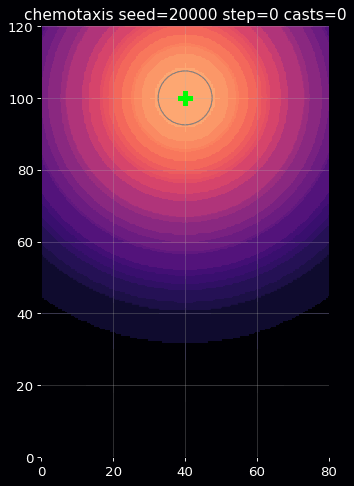

In [7]:
import os
from IPython.display import Image as DisplayImage, display
from src.utils.plotter import render_rollout_frame, save_gif

# Default to a mild-noise condition where the baseline reliably succeeds, so the
# GIF is a clean, short trajectory. Bump GIF_STAGE/STRENGTH to see it struggle
# under turbulence. Same seed → fully reproducible trajectory + plume.
GIF_STAGE = 0
GIF_STRENGTH = 0.0
GIF_SEED = None            # None = auto-pick the first successful episode; or set an int

chosen = GIF_SEED
if chosen is None:
    chosen = EVAL_SEED_BASE   # fall back to the first seed if none succeed
    for i in range(200):
        s = EVAL_SEED_BASE + i
        env = make_env(GIF_STAGE, GIF_STRENGTH, s)
        rr = run_episode(env, controller, seed=s)
        if rr['success']:
            chosen = s; break
print('rendering seed', chosen)

env = make_env(GIF_STAGE, GIF_STRENGTH, chosen)
result = run_episode(env, controller, seed=chosen, collect_traj=True,
                     render_fn=render_rollout_frame)
print(f"seed={result['seed']} return={result['return']:.2f} "
      f"success={result['success']} casts={result['casts']} steps={result['steps']}")

os.makedirs('runs/baseline_chemotaxis/plots', exist_ok=True)
gif_path = f'runs/baseline_chemotaxis/plots/agent_seed{chosen}.gif'
save_gif(result['frames'], gif_path, fps=15)
display(DisplayImage(data=open(gif_path, 'rb').read(), format='gif'))

## Noise sweep — robustness curve
Success rate across the full curriculum (`stage` × `strength`). The clean field is 100%; turbulence degrades it gracefully. This curve is the sensor-only baseline the connectome / GRU policies are measured against.

In [ ]:
import json
import matplotlib.pyplot as plt

SWEEP = [
    (0, 0.0), (1, 0.3), (1, 0.6), (1, 1.0),
    (2, 0.3), (2, 0.6), (2, 1.0),
]
SWEEP_EPISODES = 60   # per condition (lower than EVAL_EPISODES for speed)

rows = [evaluate(stage, strength, n_episodes=SWEEP_EPISODES) for stage, strength in SWEEP]

print(f"{'stage':>5} {'α':>4} {'success':>8} {'steps(succ)':>12} {'return':>8} {'casts':>7} {'cast%':>7}")
for r in rows:
    print(f"{r['stage']:>5} {r['strength']:>4.1f} {r['success_rate']:>7.0%} "
          f"{r['mean_steps_success']:>12.0f} {r['mean_return']:>8.2f} "
          f"{r['mean_casts']:>7.1f} {r['cast_fraction']:>6.1%}")

labels = [f"s{r['stage']}·α{r['strength']}" for r in rows]
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].bar(labels, [r['success_rate'] for r in rows], color=ACCENT)
ax[0].set_ylim(0, 1); ax[0].set_ylabel('success rate')
ax[0].set_title('Success ratio')
ax[0].tick_params(axis='x', rotation=30)
ax[1].bar(labels, [r['mean_steps_success'] for r in rows], color=ACCENT)
ax[1].set_ylabel('steps to source')
ax[1].set_title('Steps to source')
ax[1].tick_params(axis='x', rotation=30)
ax[2].bar(labels, [100.0 * r['cast_fraction'] for r in rows], color=ACCENT)
ax[2].set_ylabel('cast steps (%)')
ax[2].set_title('Cast fraction')
ax[2].tick_params(axis='x', rotation=30)
fig.tight_layout()
os.makedirs('runs/baseline_chemotaxis', exist_ok=True)
fig.savefig('runs/baseline_chemotaxis/noise_sweep.png', dpi=150)
with open('runs/baseline_chemotaxis/noise_sweep.json', 'w') as f:
    json.dump(rows, f, indent=2)
plt.show()
print('\n[saved] runs/baseline_chemotaxis/noise_sweep.{png,json}')


## Cast-aggressiveness sweep — "cast를 더 자주 하면?"

기본 컨트롤러는 신호를 잃었을 때만 cast한다 (`cast_after_weak_steps=4`, `weak_frac=0.35`).
여기서는 **cast 진입 임계를 완화**해 — `cast_after_weak_steps`를 낮추고 `weak_frac`를 높여 — 신호가 조금만 약해져도 cast하도록 만든 여러 변형을 같은 noise 조건에서 비교한다.
질문: cast를 더 자주 하는 게 turbulence에서 robust한가, 아니면 그냥 시간만 낭비하나?


In [ ]:
import json
import matplotlib.pyplot as plt

# Cast-aggressiveness variants. Lower `cast_after_weak_steps` + higher `weak_frac`
# => enters cast on weaker / shorter signal dropouts (casts more eagerly).
# All other knobs inherit from CTRL_KW so only the cast-trigger changes.
CAST_VARIANTS = {
    "default (weak4/0.35)":   dict(cast_after_weak_steps=4, weak_frac=0.35),
    "eager  (weak2/0.50)":    dict(cast_after_weak_steps=2, weak_frac=0.50),
    "aggr.  (weak1/0.65)":    dict(cast_after_weak_steps=1, weak_frac=0.65),
}

# Noise condition to compare the variants at (turbulent — where cast should matter).
CAST_SWEEP_STAGE = 2
CAST_SWEEP_STRENGTH = 1.0
CAST_SWEEP_EPISODES = 60

def evaluate_ctrl(ctrl, stage, strength, n_episodes, seed_base=EVAL_SEED_BASE):
    """Same metrics as `evaluate`, but for an arbitrary controller instance."""
    succ, steps, rets, casts = [], [], [], []
    for i in range(n_episodes):
        seed = seed_base + i
        env = make_env(stage, strength, seed)
        r = run_episode(env, ctrl, seed=seed)
        succ.append(int(r['success'])); steps.append(r['steps'])
        rets.append(r['return']); casts.append(r['casts'])
    succ = np.asarray(succ); steps = np.asarray(steps); casts = np.asarray(casts)
    succ_steps = steps[succ == 1]
    return {
        'success_rate': float(succ.mean()),
        'mean_steps_success': float(succ_steps.mean()) if len(succ_steps) else float('nan'),
        'mean_return': float(np.mean(rets)),
        'mean_casts': float(casts.mean()),
        'cast_fraction': float((casts / np.maximum(steps, 1)).mean()),
    }

cast_rows = []
for name, override in CAST_VARIANTS.items():
    ctrl = BilateralChemotaxis(ChemotaxisConfig(**{**CTRL_KW, **override}))
    m = evaluate_ctrl(ctrl, CAST_SWEEP_STAGE, CAST_SWEEP_STRENGTH, CAST_SWEEP_EPISODES)
    m['variant'] = name
    cast_rows.append(m)

print(f"cast variants @ stage{CAST_SWEEP_STAGE}·α{CAST_SWEEP_STRENGTH}  ({CAST_SWEEP_EPISODES} eps)\n")
print(f"{'variant':>22} {'success':>8} {'steps(succ)':>12} {'return':>8} {'casts':>7} {'cast%':>7}")
for r in cast_rows:
    print(f"{r['variant']:>22} {r['success_rate']:>7.0%} "
          f"{r['mean_steps_success']:>12.0f} {r['mean_return']:>8.2f} "
          f"{r['mean_casts']:>7.1f} {r['cast_fraction']:>6.1%}")

names = [r['variant'] for r in cast_rows]
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].bar(names, [r['success_rate'] for r in cast_rows], color=ACCENT)
ax[0].set_ylim(0, 1); ax[0].set_ylabel('success rate')
ax[0].set_title('Success ratio')
ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(names, [r['mean_steps_success'] for r in cast_rows], color=ACCENT)
ax[1].set_ylabel('steps to source')
ax[1].set_title('Steps to source')
ax[1].tick_params(axis='x', rotation=20)
ax[2].bar(names, [100.0 * r['cast_fraction'] for r in cast_rows], color=ACCENT)
ax[2].set_ylabel('cast steps (%)')
ax[2].set_title('Cast fraction')
ax[2].tick_params(axis='x', rotation=20)
fig.tight_layout()
os.makedirs('runs/baseline_chemotaxis', exist_ok=True)
fig.savefig('runs/baseline_chemotaxis/cast_sweep.png', dpi=150)
with open('runs/baseline_chemotaxis/cast_sweep.json', 'w') as f:
    json.dump(cast_rows, f, indent=2)
plt.show()
print('\n[saved] runs/baseline_chemotaxis/cast_sweep.{png,json}')


## Average steps-to-goal on successful episodes

For each noise condition, the **average number of steps to reach the source** — computed **only over episodes that succeeded** (failed episodes run out the clock and would bias the mean). Uses the same `evaluate()` and `controller` defined above.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Conditions to report avg steps-to-goal for (reuse the sweep grid).
STEPS_CONDITIONS = [
    (0, 0.0), (1, 0.3), (1, 0.6), (1, 1.0),
    (2, 0.3), (2, 0.6), (2, 1.0),
]
STEPS_EPISODES = 60   # episodes per condition

print(f"Avg steps-to-goal over SUCCESSFUL episodes ({STEPS_EPISODES} eps/condition)\n")
print(f"{'stage':>5} {'α':>4} {'#success':>9} {'avg steps':>10} {'std':>7} {'min':>6} {'max':>6}")

steps_rows = []
for stage, strength in STEPS_CONDITIONS:
    # Collect per-episode steps, keeping only successful episodes.
    succ_steps = []
    for i in range(STEPS_EPISODES):
        seed = EVAL_SEED_BASE + i
        env = make_env(stage, strength, seed)
        r = run_episode(env, controller, seed=seed)
        if r['success']:
            succ_steps.append(r['steps'])
    succ_steps = np.asarray(succ_steps, dtype=float)
    n_succ = len(succ_steps)
    avg = float(succ_steps.mean()) if n_succ else float('nan')
    std = float(succ_steps.std())  if n_succ else float('nan')
    lo  = float(succ_steps.min())  if n_succ else float('nan')
    hi  = float(succ_steps.max())  if n_succ else float('nan')
    steps_rows.append({'stage': stage, 'strength': strength, 'n_success': n_succ,
                       'avg_steps_success': avg, 'std_steps_success': std,
                       'min_steps': lo, 'max_steps': hi})
    print(f"{stage:>5} {strength:>4.1f} {n_succ:>9} {avg:>10.1f} {std:>7.1f} {lo:>6.0f} {hi:>6.0f}")

# Bar chart — same slide style as presentation_assets/ (short title, ACCENT, light grid).
labels = [f"s{r['stage']}·α{r['strength']}" for r in steps_rows]
avgs   = [r['avg_steps_success'] for r in steps_rows]
stds   = [r['std_steps_success'] for r in steps_rows]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(labels, avgs, yerr=stds, color=ACCENT, capsize=4)
ax.set_ylabel('steps to source')
ax.set_title('Steps to source')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
os.makedirs('runs/baseline_chemotaxis', exist_ok=True)
fig.savefig('runs/baseline_chemotaxis/steps_to_goal.png', dpi=150)
with open('runs/baseline_chemotaxis/steps_to_goal.json', 'w') as f:
    json.dump(steps_rows, f, indent=2)
plt.show()
print('\n[saved] runs/baseline_chemotaxis/steps_to_goal.{png,json}')
